# Compare JobB (Deceuninck) vs JobA (Real-IAD)

Cross-dataset comparison of the three feature-based models (PatchCore, PaDiM, SubspaceAD) under the current methodology baseline (`val_f1` + patched splitter).

Sections:
1. **Setup** — paths, model list.
2. **Loaders** — JobA val_defect (19 cats × 3 models), JobB val_defect (1 cell × 3 models), JobB clean (val_quantile, single cell × 3 models).
3. **§A — JobB internals**: clean (val_quantile) ↔ val_defect (val_f1) on Deceuninck.
4. **§B — JobA per-model headline (val_f1)**.
5. **§C — Cross-dataset side-by-side**: per-model JobA mean ↔ JobB single cell.
6. **§D — Per-defect breakdown** (Deceuninck has 5 defect types, JobA has per-cat defect dictionaries).
7. **§E — Plots**: cross-dataset bars, runtime cost frontier.

Key reading: [METHOD.md §5](../METHOD.md#5-dataset-structures-and-how-they-shaped-the-methodology) on dataset-shape differences (test prevalence, specimen grouping, defect-class skew) that bound how comparable JobA and JobB cells really are.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

OUTPUTS = REPO / "data" / "outputs"
JOBA_VD_DIR = OUTPUTS / "jobA_val_defect_V1"
JOBB_VD_DIR = OUTPUTS / "jobB_val_defect_deceuninck_20260427_102501"
JOBB_CLEAN_PARENT = OUTPUTS / "jobB v0_deceuninck_20260425_101433-20260426T101905Z-3-001"
JOBB_CLEAN_DIR = JOBB_CLEAN_PARENT / "jobB_deceuninck_20260425_101433"

ANALYSIS_DIR = OUTPUTS / "jobB_val_defect_deceuninck_20260427_102501" / "_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["anomalib_patchcore", "anomalib_padim", "subspacead"]
METRICS = [
    "auroc", "aupr", "f1", "precision", "recall", "accuracy",
    "recall_at_fpr_1pct", "recall_at_fpr_5pct",
    "macro_recall", "weighted_recall",
    "ms_per_image", "fps", "peak_vram_mb", "fit_seconds", "predict_seconds",
    "threshold_mode", "threshold_used",
    "train_samples", "val_samples", "test_samples",
    "val_precision", "val_recall", "val_f1", "val_auroc", "val_aupr",
]

for label, path in [("JobA val_defect", JOBA_VD_DIR),
                    ("JobB val_defect", JOBB_VD_DIR),
                    ("JobB clean    ", JOBB_CLEAN_DIR)]:
    print(f"{label}: exists={path.exists()}  ->  {path}")

JobA val_defect: exists=True  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1
JobB val_defect: exists=True  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_deceuninck_20260427_102501
JobB clean    : exists=True  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB v0_deceuninck_20260425_101433-20260426T101905Z-3-001\jobB_deceuninck_20260425_101433


## 2. Loaders

JobA uses one directory per (cat, run) so we walk and join. JobB has one directory per run with all three models inside the same `benchmark_summary.json`, so we read directly.

In [2]:
_TS_TAIL = r"_\d{8}_\d{6}$"


def _category_from_dirname(name: str, prefix: str) -> str | None:
    m = re.match(rf"^{re.escape(prefix)}(.+){_TS_TAIL}", name)
    return m.group(1) if m else None


def _entry_to_row(entry: dict, category: str) -> dict:
    row = {"category": category, "model": entry.get("model")}
    for k in METRICS:
        row[k] = entry.get(k)
    row["per_defect_recall"] = entry.get("per_defect_recall") or {}
    row["per_defect_support"] = entry.get("per_defect_support") or {}
    return row


def load_joba_vd(directory: Path) -> pd.DataFrame:
    rows: dict[tuple[str, str], dict] = {}
    if not directory.exists():
        return pd.DataFrame()
    for d in sorted(directory.iterdir()):
        if not d.is_dir() or "_anomalib_" in d.name or "_rd4ad_" in d.name:
            continue
        category = _category_from_dirname(d.name, "jobA_val_defect_")
        if category is None:
            continue
        fp = d / "benchmark_summary.json"
        if not fp.exists():
            continue
        data = json.loads(fp.read_text())
        for entry in data.get("models", []):
            if entry.get("model") not in MODELS:
                continue
            key = (category, entry["model"])
            prev = rows.get(key)
            if prev is None or d.name > prev["_dir"]:
                row = _entry_to_row(entry, category)
                row["_dir"] = d.name
                rows[key] = row
    df = pd.DataFrame(rows.values())
    if not df.empty:
        df = df.sort_values(["category", "model"]).reset_index(drop=True)
    return df


def load_jobb(run_dir: Path, category: str = "deceuninck") -> pd.DataFrame:
    """Load a single JobB run directory (one bundle, three models)."""
    fp = run_dir / "benchmark_summary.json"
    if not fp.exists():
        return pd.DataFrame()
    data = json.loads(fp.read_text())
    rows = [_entry_to_row(e, category) for e in data.get("models", [])
            if e.get("model") in MODELS]
    return pd.DataFrame(rows)


df_jobA_vd = load_joba_vd(JOBA_VD_DIR)
df_jobB_vd = load_jobb(JOBB_VD_DIR)
df_jobB_clean = load_jobb(JOBB_CLEAN_DIR)

print(f"JobA val_defect : {len(df_jobA_vd)} cells  ({df_jobA_vd['category'].nunique()} cats)")
print(f"JobB val_defect : {len(df_jobB_vd)} cells  (mode={df_jobB_vd['threshold_mode'].iloc[0] if not df_jobB_vd.empty else '-'})")
print(f"JobB clean      : {len(df_jobB_clean)} cells  (mode={df_jobB_clean['threshold_mode'].iloc[0] if not df_jobB_clean.empty else '-'})")

JobA val_defect : 90 cells  (30 cats)
JobB val_defect : 3 cells  (mode=val_f1)
JobB clean      : 3 cells  (mode=val_quantile)


## §A — JobB internals: clean (val_quantile) ↔ val_defect (val_f1)

Confirms the calibration switch behaves on Deceuninck the same way it does on Real-IAD: AUROC stable, F1/Recall up, threshold permissive. Caveat: Deceuninck is so easy that both runs already saturate near 1.0 — the lift is small in absolute terms because there is little room to move.

In [3]:
# Side-by-side per model, plus delta. Drop industrial metrics for the clean run (val_quantile baseline didn't emit them).
core_cols = ["auroc", "aupr", "f1", "precision", "recall", "threshold_used",
             "ms_per_image", "fps", "peak_vram_mb"]
merged_jobB = df_jobB_clean.merge(df_jobB_vd, on=["category", "model"],
                                  suffixes=("_clean", "_vd"))
for c in ("auroc", "aupr", "f1", "precision", "recall"):
    merged_jobB[f"d{c}"] = merged_jobB[f"{c}_vd"] - merged_jobB[f"{c}_clean"]
merged_jobB["thr_ratio"] = merged_jobB["threshold_used_vd"] / merged_jobB["threshold_used_clean"]

show_cols = ["model",
             "auroc_clean", "auroc_vd", "dauroc",
             "f1_clean", "f1_vd", "df1",
             "recall_clean", "recall_vd", "drecall",
             "precision_clean", "precision_vd", "dprecision",
             "threshold_used_clean", "threshold_used_vd", "thr_ratio"]
merged_jobB[show_cols].round(4)

,model,auroc_clean,auroc_vd,dauroc,f1_clean,f1_vd,df1,recall_clean,recall_vd,drecall,precision_clean,precision_vd,dprecision,threshold_used_clean,threshold_used_vd,thr_ratio
0,anomalib_patchcore,1.0000,1.0000,0.0000,0.9918,1.0000,0.0082,1.0000,1.0000,0.0000,0.9837,1.0,0.0163,19.6144,37.6074,1.9173
1,anomalib_padim,0.9953,0.9999,0.0046,0.9969,0.9977,0.0008,0.9979,0.9954,-0.0025,0.9959,1.0,0.0041,52.4909,70.0831,1.3351
2,subspacead,0.9991,1.0000,0.0009,0.9928,0.9988,0.0061,1.0000,0.9977,-0.0023,0.9857,1.0,0.0143,10.8623,6.6127,0.6088


In [4]:
# Test-set composition shifts because val_defect routed 10% of bads into val.
size_cols = ["model", "train_samples", "val_samples", "test_samples"]
left = df_jobB_clean[size_cols].copy(); left["variant"] = "clean (val_quantile)"
right = df_jobB_vd[size_cols].copy(); right["variant"] = "val_defect (val_f1)"
pd.concat([left, right]).pivot_table(index="variant", columns="model",
                                     values=["train_samples", "val_samples", "test_samples"],
                                     aggfunc="first")

test_samples                                \
model                anomalib_padim anomalib_patchcore subspacead   
variant                                                             
clean (val_quantile)            527                527        527   
val_defect (val_f1)             478                478        478   

                      train_samples                                \
model                anomalib_padim anomalib_patchcore subspacead   
variant                                                             
clean (val_quantile)            161                161        161   
val_defect (val_f1)             161                161        161   

                        val_samples                                
model                anomalib_padim anomalib_patchcore subspacead  
variant                                                            
clean (val_quantile)             18                 18         18  
val_defect (val_f1)              67                 67         67

## §B — JobA per-model headline (val_f1)

Means, medians and stdev over whichever JobA categories currently have a val_defect rerun. Shown so the JobB cells in §C are read against a clear central tendency, not a moving target.

In [5]:
n_cats = df_jobA_vd["category"].nunique()
agg_cols = ["auroc", "aupr", "f1", "precision", "recall",
            "recall_at_fpr_1pct", "recall_at_fpr_5pct",
            "macro_recall", "weighted_recall",
            "ms_per_image", "fps", "peak_vram_mb"]
jobA_mean = df_jobA_vd.groupby("model")[agg_cols].mean().round(4)
jobA_median = df_jobA_vd.groupby("model")[agg_cols].median().round(4)
jobA_std = df_jobA_vd.groupby("model")[agg_cols].std().round(4)

print(f"=== JobA val_defect — per-model MEAN over {n_cats} cats ===")
print(jobA_mean.to_string())
print("\n=== JobA val_defect — per-model MEDIAN ===")
print(jobA_median.to_string())
print("\n=== JobA val_defect — per-model STDEV (variability across cats) ===")
print(jobA_std.to_string())

=== JobA val_defect — per-model MEAN over 30 cats ===
                     auroc    aupr      f1  precision  recall  recall_at_fpr_1pct  recall_at_fpr_5pct  macro_recall  weighted_recall  ms_per_image       fps  peak_vram_mb
model                                                                                                                                                                     
anomalib_padim      0.9022  0.9729  0.9287     0.9484  0.9129              0.2157              0.5889        0.9056           0.9040       10.2126  101.0182     4480.3271
anomalib_patchcore  0.8701  0.9678  0.9046     0.9308  0.8843              0.3364              0.4898        0.8731           0.8732      113.5760   10.5325    13968.8689
subspacead          0.8615  0.9662  0.8811     0.9298  0.8426              0.3507              0.4968        0.8182           0.8192      103.3303    9.6933     1786.4063

=== JobA val_defect — per-model MEDIAN ===
                     auroc    aupr      f1  pre

## §C — Cross-dataset side-by-side

Per-model: JobA val_f1 mean (± stdev across the JobA cats) vs JobB val_f1 single cell. The asymmetry of this comparison is the point — JobA is a *spread* over many different categories, JobB is a single industrial dataset.

In [6]:
compare_cols = ["auroc", "aupr", "f1", "precision", "recall",
                "recall_at_fpr_1pct", "recall_at_fpr_5pct",
                "macro_recall", "weighted_recall",
                "ms_per_image", "fps", "peak_vram_mb"]

side_by_side = []
jobB_lookup = df_jobB_vd.set_index("model")
for m in MODELS:
    sub = df_jobA_vd[df_jobA_vd["model"] == m]
    jb = jobB_lookup.loc[m] if m in jobB_lookup.index else None
    row = {"model": m}
    for col in compare_cols:
        row[f"{col}_jobA_mean"] = sub[col].mean()
        row[f"{col}_jobA_std"] = sub[col].std()
        row[f"{col}_jobB"] = (jb[col] if jb is not None else np.nan)
        row[f"{col}_diff"] = row[f"{col}_jobB"] - row[f"{col}_jobA_mean"]
    side_by_side.append(row)
df_compare = pd.DataFrame(side_by_side).round(4)
df_compare.to_csv(ANALYSIS_DIR / "compare_jobB_vs_jobA.tsv", sep="\t", index=False)
print(f"Wrote {ANALYSIS_DIR / 'compare_jobB_vs_jobA.tsv'}")
df_compare

Wrote C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_deceuninck_20260427_102501\_analysis\compare_jobB_vs_jobA.tsv


,model,auroc_jobA_mean,auroc_jobA_std,auroc_jobB,auroc_diff,aupr_jobA_mean,aupr_jobA_std,aupr_jobB,aupr_diff,f1_jobA_mean,...,ms_per_image_jobB,ms_per_image_diff,fps_jobA_mean,fps_jobA_std,fps_jobB,fps_diff,peak_vram_mb_jobA_mean,peak_vram_mb_jobA_std,peak_vram_mb_jobB,peak_vram_mb_diff
0,anomalib_patchcore,0.8701,0.0878,1.0000,0.1299,0.9678,0.0240,1.0,0.0322,0.9046,...,334.2353,220.6593,10.5325,5.5391,2.9919,-7.5406,13968.8689,5455.0098,12430.021,-1538.8479
1,anomalib_padim,0.9022,0.0751,0.9999,0.0977,0.9729,0.0193,1.0,0.0271,0.9287,...,20.2265,10.0139,101.0182,20.0722,49.4400,-51.5781,4480.3271,1742.4552,4202.877,-277.4501
2,subspacead,0.8615,0.0743,1.0000,0.1385,0.9662,0.0203,1.0,0.0338,0.8811,...,374.4562,271.1259,9.6933,0.4076,2.6705,-7.0227,1786.4063,240.1051,1918.379,131.9727


In [7]:
# Compact reading for the thesis table: AUROC, F1, Recall, ms/img, peak_vram.
thesis_cols = ["auroc", "aupr", "f1", "recall",
               "recall_at_fpr_1pct", "macro_recall",
               "ms_per_image", "fps", "peak_vram_mb"]
rows = []
for m in MODELS:
    sub = df_jobA_vd[df_jobA_vd["model"] == m]
    jb = df_jobB_vd[df_jobB_vd["model"] == m]
    name = m.replace("anomalib_", "")
    for col in thesis_cols:
        rows.append({
            "model": name,
            "metric": col,
            "JobA mean": round(sub[col].mean(), 4),
            "JobA std": round(sub[col].std(), 4),
            "JobA min": round(sub[col].min(), 4),
            "JobA max": round(sub[col].max(), 4),
            "JobB": round(float(jb[col].iloc[0]), 4) if not jb.empty else np.nan,
        })
thesis_table = pd.DataFrame(rows)
thesis_table.to_csv(ANALYSIS_DIR / "thesis_table_jobB_vs_jobA.tsv", sep="\t", index=False)
print(f"Wrote {ANALYSIS_DIR / 'thesis_table_jobB_vs_jobA.tsv'}")
thesis_table

Wrote C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_deceuninck_20260427_102501\_analysis\thesis_table_jobB_vs_jobA.tsv


,model,metric,JobA mean,JobA std,JobA min,JobA max,JobB
0,patchcore,auroc,0.8701,0.0878,0.6588,0.9890,1.0000
1,patchcore,aupr,0.9678,0.0240,0.9064,0.9977,1.0000
2,patchcore,f1,0.9046,0.0451,0.7880,0.9836,1.0000
3,patchcore,recall,0.8843,0.0772,0.7187,0.9978,1.0000
4,patchcore,recall_at_fpr_1pct,0.3364,0.1254,0.0581,0.5462,1.0000
5,patchcore,macro_recall,0.8731,0.0797,0.7197,0.9978,1.0000
6,patchcore,ms_per_image,113.5760,36.8934,46.9218,137.9780,334.2353
7,patchcore,fps,10.5325,5.5391,7.2475,21.3120,2.9919
8,patchcore,peak_vram_mb,13968.8689,5455.0098,4400.5210,17479.0210,12430.0210
9,padim,auroc,0.9022,0.0751,0.6980,0.9830,0.9999


## §D — Per-defect breakdown

Deceuninck has 5 defect types (one — *Scratch in extrusion direction* — accounts for ~80% of bads). JobA categories each have their own defect dictionary (4 types per cat). The two are not joinable; we show them separately.

In [8]:
def _explode_per_defect(df: pd.DataFrame) -> pd.DataFrame:
    out = []
    for _, r in df.iterrows():
        per = r["per_defect_recall"] or {}
        sup = r["per_defect_support"] or {}
        for dtype in sorted(per.keys()):
            out.append({
                "category": r["category"],
                "model": r["model"].replace("anomalib_", ""),
                "defect_type": dtype,
                "support": sup.get(dtype, 0),
                "recall": per[dtype],
            })
    return pd.DataFrame(out)

perdef_jobB = _explode_per_defect(df_jobB_vd)
perdef_jobA = _explode_per_defect(df_jobA_vd)

print("=== JobB per-defect recall (val_f1) ===")
print(perdef_jobB.pivot_table(index="defect_type", columns="model",
                              values="recall").to_string())
print("\nSupport per defect type:")
print(perdef_jobB.groupby("defect_type")["support"].first().sort_values(ascending=False).to_string())

=== JobB per-defect recall (val_f1) ===
model                              padim  patchcore  subspacead
defect_type                                                    
Black spots                     0.937500        1.0    1.000000
Cleaning felt                   1.000000        1.0    1.000000
Degassing                       1.000000        1.0    1.000000
Pigment spill                   0.947368        1.0    1.000000
Scratch in extrusion direction  1.000000        1.0    0.997167

Support per defect type:
defect_type
Scratch in extrusion direction    353
Degassing                          23
Cleaning felt                      22
Pigment spill                      19
Black spots                        16


In [9]:
# JobA per-defect recall — mean across cats per (model, defect_type).
if not perdef_jobA.empty:
    pdj = perdef_jobA.groupby(["model", "defect_type"])["recall"].mean().unstack().round(3)
    print("=== JobA per-defect recall (mean across 19 cats) ===")
    print(pdj.to_string())
else:
    print("No per-defect data in JobA val_defect cells.")

=== JobA per-defect recall (mean across 19 cats) ===
defect_type     AK     BX     CH     HS     PS     QS     YW     ZW
model                                                              
padim        0.965  0.983  0.881  0.935  0.997  0.899  0.921  0.830
patchcore    0.850  0.992  0.921  0.862  0.973  0.906  0.924  0.836
subspacead   0.857  0.987  0.812  0.791  0.947  0.794  0.943  0.797


## §E — Plots

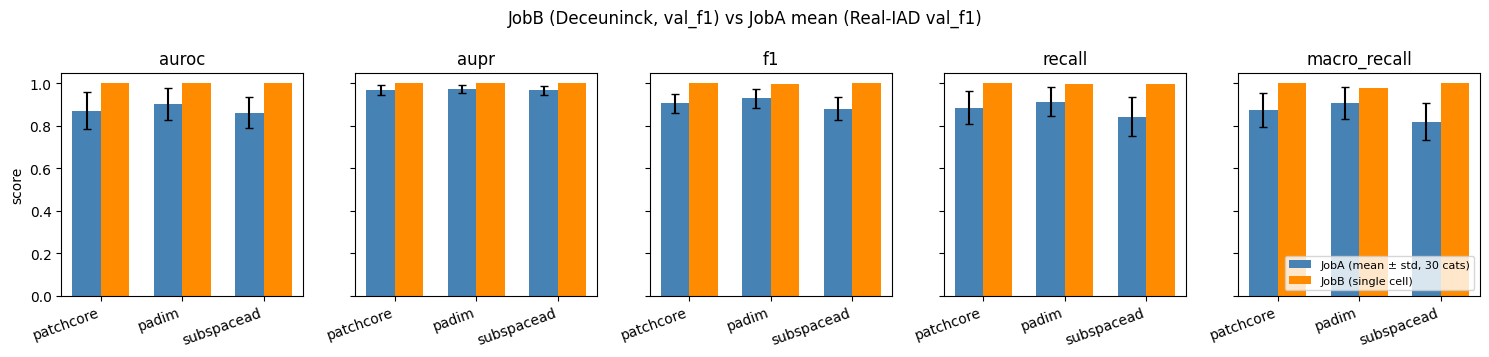

In [10]:
n_jobA_cats = df_jobA_vd["category"].nunique()
# Cross-dataset bar: AUROC + F1 + Recall, JobA mean (with std bars) vs JobB.
metrics_to_plot = ["auroc", "aupr", "f1", "recall", "macro_recall"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 3.6), sharey=True)
x = np.arange(len(MODELS))
width = 0.35
model_labels = [m.replace("anomalib_", "") for m in MODELS]
for ax, metric in zip(axes, metrics_to_plot):
    a_mean = [df_jobA_vd[df_jobA_vd["model"] == m][metric].mean() for m in MODELS]
    a_std = [df_jobA_vd[df_jobA_vd["model"] == m][metric].std() for m in MODELS]
    b_val = [float(df_jobB_vd[df_jobB_vd["model"] == m][metric].iloc[0]) if metric in df_jobB_vd.columns else np.nan for m in MODELS]
    ax.bar(x - width/2, a_mean, width, yerr=a_std, capsize=3,
           color="steelblue", label=f"JobA (mean ± std, {n_jobA_cats} cats)")
    ax.bar(x + width/2, b_val, width, color="darkorange", label="JobB (single cell)")
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha="right")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("score")
axes[-1].legend(loc="lower right", fontsize=8)
fig.suptitle("JobB (Deceuninck, val_f1) vs JobA mean (Real-IAD val_f1)")
plt.tight_layout()
plt.show()

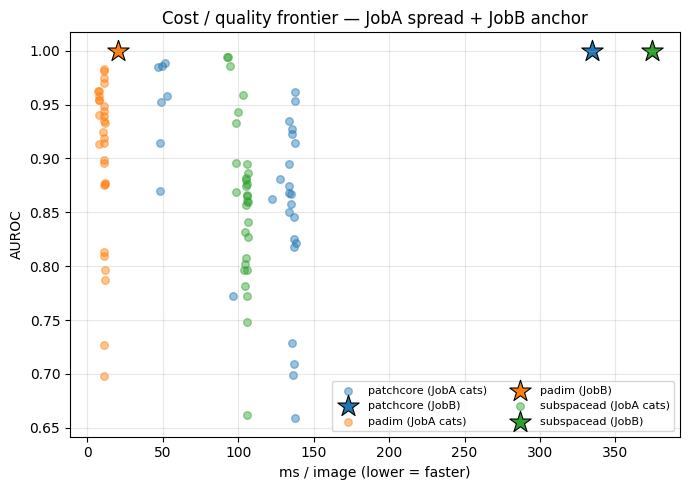

In [11]:
# Cost frontier: ms/img vs AUROC, JobA cells (small dots) + JobB (large markers).
fig, ax = plt.subplots(figsize=(7, 5))
for m, color in zip(MODELS, ["tab:blue", "tab:orange", "tab:green"]):
    sub = df_jobA_vd[df_jobA_vd["model"] == m]
    ax.scatter(sub["ms_per_image"], sub["auroc"], color=color, alpha=0.45,
               s=30, label=f"{m.replace('anomalib_', '')} (JobA cats)")
    jb = df_jobB_vd[df_jobB_vd["model"] == m]
    if not jb.empty:
        ax.scatter(jb["ms_per_image"], jb["auroc"], color=color, marker="*",
                   s=260, edgecolor="black", linewidth=0.8,
                   label=f"{m.replace('anomalib_', '')} (JobB)")
ax.set_xlabel("ms / image (lower = faster)")
ax.set_ylabel("AUROC")
ax.set_title("Cost / quality frontier — JobA spread + JobB anchor")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

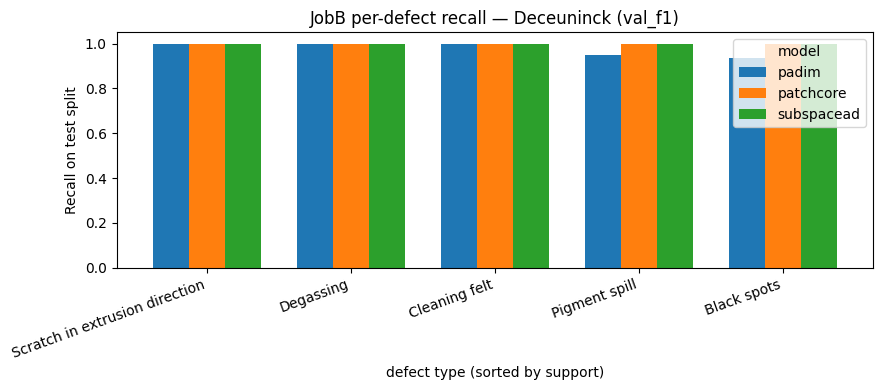

In [12]:
# Per-defect bar (JobB only — JobA defect names vary per cat).
if not perdef_jobB.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    pivot = perdef_jobB.pivot_table(index="defect_type", columns="model",
                                    values="recall")
    pivot = pivot.loc[perdef_jobB.groupby("defect_type")["support"]
                      .first().sort_values(ascending=False).index]
    pivot.plot(kind="bar", ax=ax, width=0.75)
    ax.set_ylabel("Recall on test split")
    ax.set_xlabel("defect type (sorted by support)")
    ax.set_title("JobB per-defect recall — Deceuninck (val_f1)")
    ax.set_ylim(0, 1.05)
    ax.legend(title="model")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

---

## Headline reading

1. **Detection quality** — Deceuninck saturates at AUROC ~1.0 across the 3 models because the dataset is easy (high prevalence, single product line, well-lit). Model selection on JobB is *not* driven by detection quality.
2. **Cost/quality frontier** — PaDiM dominates JobB on ms/img and peak_vram while staying inside the saturated quality band. On JobA the same pattern roughly holds (PaDiM wins per-cat AUROC most often, see [analyze jobA.ipynb](analyze%20jobA.ipynb) §A).
3. **Per-defect** — on Deceuninck, all 5 defect types are detected with recall ≈ 1.0 in the val_f1 setup. The dominant *Scratch* class (~80% of bads) does not visibly distort the per-class breakdown for these three models.
4. **Calibration sanity** — JobB clean ↔ val_defect agrees with the JobA pattern (§A): AUROC stable, F1/Recall up at the new operating point. The lift is small in absolute terms because the clean baseline was already near 1.0.

## Pointers

- Companion notebook (single-job analysis): [analyze jobA.ipynb](analyze%20jobA.ipynb)
- Methodology context: [METHOD.md §5 + §7](../METHOD.md)
- Project plan / status snapshot: [PLAN.md](../PLAN.md)
- TSV outputs land under `data/outputs/jobB_val_defect_deceuninck_*/_analysis/`.